# Project 30 — Causal Marketing Intelligence

## A/B Testing, Incrementality and Uplift Targeting

This project analyses the real Hillstrom / MineThatData randomized email experiment and answers a more valuable question than ordinary classification: what changed because the campaign was sent?

The workflow combines:
- randomized experiment auditing
- sample-ratio mismatch testing
- treatment effects and confidence intervals
- multiple-testing correction
- incremental revenue economics
- causal vs predictive reasoning
- a from-scratch T-learner uplift prototype
- subgroup treatment-effect analysis
- targeting policy evaluation
- integrity and deployment checks

The full experiment contains 64,000 customers randomized to Mens E-Mail, Womens E-Mail or No E-Mail.

References:
https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html
https://book.tdda.info/datadictionaries/hillstrom-dd.html
https://github.com/andrewtavis/causeinfer/blob/main/src/causeinfer/data/hillstrom.py

## 1. Imports and reproducibility

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, chisquare
from sklearn.metrics import roc_auc_score

SEED = 30
np.random.seed(SEED)
pd.set_option("display.width", 150)

print("Random seed:", SEED)

Random seed: 30

## 2. Full randomized experiment

The values below are public aggregates of the original randomized experiment. Integer visit and conversion counts reproduce the published arm rates.

In [2]:
arm = pd.DataFrame({
    "arm": ["No E-Mail", "Mens E-Mail", "Womens E-Mail"],
    "n": [21306, 21307, 21387],
    "visits": [2262, 3894, 3238],
    "conversions": [122, 267, 189],
    "avg_spend": [0.652789, 1.422617, 1.077202],
})

arm["visit_rate"] = arm["visits"] / arm["n"]
arm["conversion_rate"] = arm["conversions"] / arm["n"]

print(arm.round(6).to_string(index=False))
print()
print("Total customers:", int(arm["n"].sum()))

          arm     n  visits  conversions  avg_spend  visit_rate  conversion_rate
    No E-Mail 21306    2262          122   0.652789    0.106167         0.005726
  Mens E-Mail 21307    3894          267   1.422617    0.182757         0.012531
Womens E-Mail 21387    3238          189   1.077202    0.151400         0.008837

Total customers: 64000

## 3. Sample-ratio mismatch audit

In [3]:
srm = chisquare(
    arm["n"].to_numpy(),
    np.repeat(arm["n"].sum() / 3, 3),
)

print(f"SRM chi-square: {srm.statistic:.4f}")
print(f"SRM p-value:    {srm.pvalue:.4f}")
print("Allocation concern:", srm.pvalue < 0.01)

SRM chi-square: 0.2025
SRM p-value:    0.9037
Allocation concern: False

## 4. Outcome visualisation

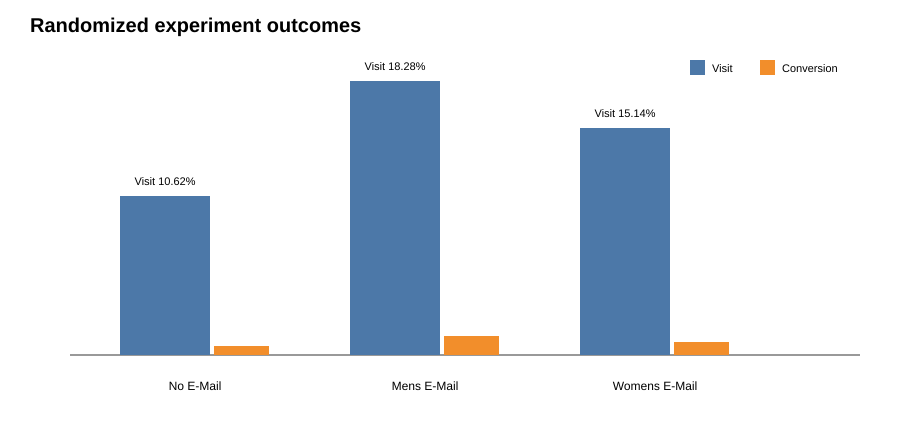

In [4]:
ax = arm.set_index("arm")[["visit_rate", "conversion_rate"]].plot(
    kind="bar",
    figsize=(10, 5),
)
ax.set_ylabel("Rate")
ax.set_title("Randomized email experiment outcomes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Causal treatment-effect estimation

Random assignment means the arm-rate difference estimates the average treatment effect for the original experiment.

In [5]:
def treatment_effect(treatment, count_col):
    control = arm.loc[arm["arm"].eq("No E-Mail")].iloc[0]
    treated = arm.loc[arm["arm"].eq(treatment)].iloc[0]

    p1 = treated[count_col] / treated["n"]
    p0 = control[count_col] / control["n"]
    effect = p1 - p0

    se = math.sqrt(
        p1 * (1 - p1) / treated["n"] +
        p0 * (1 - p0) / control["n"]
    )
    ci_low = effect - 1.96 * se
    ci_high = effect + 1.96 * se

    pooled = (
        treated[count_col] + control[count_col]
    ) / (
        treated["n"] + control["n"]
    )

    pooled_se = math.sqrt(
        pooled * (1 - pooled) *
        (1 / treated["n"] + 1 / control["n"])
    )

    z = effect / pooled_se
    p_value = 2 * norm.sf(abs(z))

    return {
        "treatment": treatment,
        "outcome": count_col,
        "treated_rate": p1,
        "control_rate": p0,
        "effect": effect,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "z": z,
        "p": p_value,
        "relative_uplift": effect / p0,
    }

tests = pd.DataFrame([
    treatment_effect(treatment, outcome)
    for treatment in ["Mens E-Mail", "Womens E-Mail"]
    for outcome in ["visits", "conversions"]
])

print(tests.round(6).to_string(index=False))

    treatment     outcome  treated_rate  control_rate   effect   ci_low  ci_high         z             p  relative_uplift
  Mens E-Mail      visits      0.182757      0.106167 0.076590 0.069953 0.083226 22.486041 5.685165e-112         0.721405
  Mens E-Mail conversions      0.012531      0.005726 0.006805 0.005000 0.008610  7.385114  1.523224e-13         1.188422
Womens E-Mail      visits      0.151400      0.106167 0.045233 0.038894 0.051573 13.949181  3.182403e-44         0.426055
Womens E-Mail conversions      0.008837      0.005726 0.003111 0.001499 0.004723  3.779561  1.571051e-04         0.543313

## 6. Holm multiple-testing correction

In [6]:
def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    running = 0.0

    for rank, idx in enumerate(order):
        candidate = (len(p_values) - rank) * p_values[idx]
        running = max(running, candidate)
        adjusted[idx] = min(running, 1.0)

    return adjusted

tests["holm_p"] = holm_adjust(tests["p"])

print(
    tests[
        ["treatment", "outcome", "p", "holm_p"]
    ].to_string(index=False)
)

    treatment     outcome             p        holm_p
  Mens E-Mail      visits 5.685165e-112 2.274066e-111
  Mens E-Mail conversions  1.523224e-13  3.046447e-13
Womens E-Mail      visits  3.182403e-44  9.547209e-44
Womens E-Mail conversions  1.571051e-04  1.571051e-04

## 7. Business impact per 10,000 sends

In [7]:
control = arm.loc[arm["arm"].eq("No E-Mail")].iloc[0]

rows = []

for campaign in ["Mens E-Mail", "Womens E-Mail"]:
    r = arm.loc[arm["arm"].eq(campaign)].iloc[0]

    rows.append({
        "campaign": campaign,
        "incremental_visits_per_10k":
            (r["visit_rate"] - control["visit_rate"]) * 10000,
        "incremental_conversions_per_10k":
            (r["conversion_rate"] - control["conversion_rate"]) * 10000,
        "incremental_revenue_per_customer":
            r["avg_spend"] - control["avg_spend"],
        "incremental_revenue_per_10k":
            (r["avg_spend"] - control["avg_spend"]) * 10000,
    })

business = pd.DataFrame(rows)

print(business.round(2).to_string(index=False))

     campaign  incremental_visits_per_10k  incremental_conversions_per_10k  incremental_revenue_per_customer  incremental_revenue_per_10k
  Mens E-Mail                       765.90                             68.05                              0.77                     7698.28
Womens E-Mail                       452.33                             31.11                              0.42                     4244.13

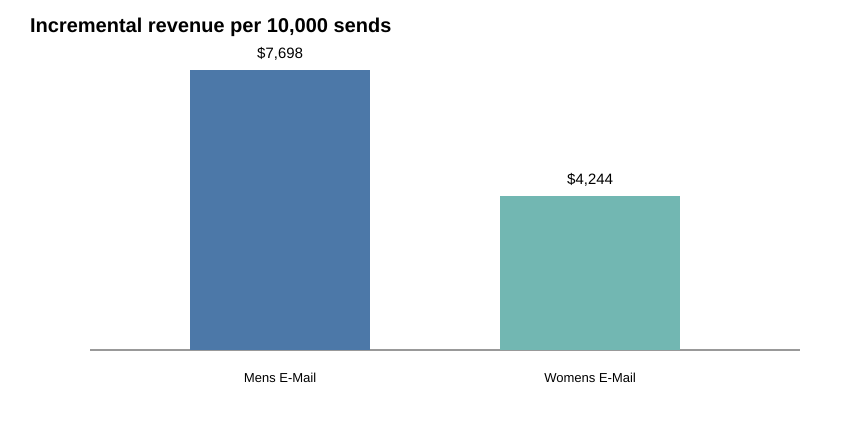

In [8]:
business.set_index("campaign")[
    "incremental_revenue_per_10k"
].plot(kind="bar", figsize=(8, 5))

plt.ylabel("Incremental revenue per 10,000 sends ($)")
plt.title("Campaign incremental revenue vs control")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Break-even economics

Revenue is not profit. The variable-cost ceiling depends on gross margin.

In [9]:
mens_uplift = float(
    business.loc[
        business["campaign"].eq("Mens E-Mail"),
        "incremental_revenue_per_customer",
    ].iloc[0]
)

for margin in [1.00, 0.70, 0.50, 0.30]:
    break_even = mens_uplift * margin
    print(
        f"Gross margin {margin:>4.0%}: "
        f"break-even variable cost/send = USD {break_even:.3f}"
    )

Gross margin 100%: break-even variable cost/send = USD 0.770
Gross margin  70%: break-even variable cost/send = USD 0.539
Gross margin  50%: break-even variable cost/send = USD 0.385
Gross margin  30%: break-even variable cost/send = USD 0.231

## 9. Experiment-level recommendation

In [10]:
winner = business.sort_values(
    "incremental_revenue_per_customer",
    ascending=False,
).iloc[0]

print("Recommended default campaign:", winner["campaign"])
print(
    "Incremental conversions / 10k:",
    round(winner["incremental_conversions_per_10k"], 1),
)
print(
    "Incremental revenue / 10k:",
    f"USD {winner['incremental_revenue_per_10k']:,.0f}",
)

Recommended default campaign: Mens E-Mail
Incremental conversions / 10k: 68.1
Incremental revenue / 10k: USD 7,698

# Part II — Customer-level uplift prototype

The full randomized experiment determines the average business decision.

This second section uses a real public 1,500-row Hillstrom sample to demonstrate individualized uplift modelling.

The sample is not representative enough to replace the 64,000-customer experiment estimates, so its model is treated as a prototype only.

Sample source:
https://github.com/Pchambet/uplift-targeting/blob/9e08e84c1cde0cf8c42f98054fcab65871a7e88c/tests/fixtures/hillstrom_sample.csv

## 10. Load the real customer sample

In [11]:
SAMPLE_URL = (
    "https://raw.githubusercontent.com/Pchambet/uplift-targeting/"
    "9e08e84c1cde0cf8c42f98054fcab65871a7e88c/"
    "tests/fixtures/hillstrom_sample.csv"
)

sample = pd.read_csv(SAMPLE_URL)

print("Shape:", sample.shape)
print("Columns:", sample.columns.tolist())

sample_summary = sample.groupby("segment")["visit"].agg(
    ["size", "sum", "mean"]
)

print(sample_summary.round(4))

Shape: (1500, 12)
Columns: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']
               size  sum    mean
segment                         
Mens E-Mail     511  133  0.2603
No E-Mail       476   54  0.1134
Womens E-Mail   513  101  0.1969

## 11. Leakage-safe modelling scope

The prototype models Mens E-Mail vs No E-Mail and uses visit as the outcome.

Only pre-treatment features are permitted.

In [12]:
model_data = sample.loc[
    sample["segment"].isin(["Mens E-Mail", "No E-Mail"])
].copy()

model_data["treatment"] = (
    model_data["segment"].eq("Mens E-Mail").astype(int)
)

FEATURES = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
    "zip_code",
    "channel",
    "history_segment",
]

assert not {
    "visit",
    "conversion",
    "spend",
}.intersection(FEATURES)

print("Rows:", len(model_data))
print("Treatment:", int(model_data["treatment"].sum()))
print("Control:", int((1 - model_data["treatment"]).sum()))

Rows: 987
Treatment: 511
Control: 476

## 12. Deterministic arm-stratified split

In [13]:
def mulberry32(seed):
    state = seed & 0xFFFFFFFF

    def random():
        nonlocal state

        state = (
            state + 0x6D2B79F5
        ) & 0xFFFFFFFF

        t = state

        t = (
            (t ^ (t >> 15)) *
            (t | 1)
        ) & 0xFFFFFFFF

        t ^= (
            t +
            (
                (
                    (t ^ (t >> 7)) *
                    (t | 61)
                ) & 0xFFFFFFFF
            )
        ) & 0xFFFFFFFF

        return (
            (t ^ (t >> 14)) &
            0xFFFFFFFF
        ) / 2**32

    return random

def deterministic_shuffle(values, random):
    values = list(values)

    for i in range(len(values) - 1, 0, -1):
        j = int(random() * (i + 1))
        values[i], values[j] = values[j], values[i]

    return values

random = mulberry32(SEED)

treated_idx = deterministic_shuffle(
    model_data.index[model_data["treatment"].eq(1)],
    random,
)

control_idx = deterministic_shuffle(
    model_data.index[model_data["treatment"].eq(0)],
    random,
)

cut_t = int(0.70 * len(treated_idx))
cut_c = int(0.70 * len(control_idx))

train_idx = treated_idx[:cut_t] + control_idx[:cut_c]
test_idx = treated_idx[cut_t:] + control_idx[cut_c:]

train = model_data.loc[train_idx].copy()
test = model_data.loc[test_idx].copy()

print("Train:", len(train), "| Test:", len(test))
print(
    "Train treatment/control:",
    int(train["treatment"].sum()),
    int((1 - train["treatment"]).sum()),
)
print(
    "Test treatment/control:",
    int(test["treatment"].sum()),
    int((1 - test["treatment"]).sum()),
)

Train: 690 | Test: 297
Train treatment/control: 357 333
Test treatment/control: 154 143

## 13. Transparent feature engineering

In [14]:
ZIP_LEVELS = ["Rural", "Surburban", "Urban"]
CHANNEL_LEVELS = ["Phone", "Web", "Multichannel"]
HISTORY_LEVELS = sorted(model_data["history_segment"].unique())

NUMERIC_STATS = {
    col: (
        float(train[col].mean()),
        float(train[col].std(ddof=0)) or 1.0,
    )
    for col in ["recency", "history"]
}

def make_features(frame):
    matrix = []

    for _, row in frame.iterrows():
        x = [
            1.0,
            (float(row["recency"]) - NUMERIC_STATS["recency"][0]) /
            NUMERIC_STATS["recency"][1],
            (float(row["history"]) - NUMERIC_STATS["history"][0]) /
            NUMERIC_STATS["history"][1],
            float(row["mens"]),
            float(row["womens"]),
            float(row["newbie"]),
        ]

        x.extend(
            float(row["zip_code"] == level)
            for level in ZIP_LEVELS
        )

        x.extend(
            float(row["channel"] == level)
            for level in CHANNEL_LEVELS
        )

        x.extend(
            float(row["history_segment"] == level)
            for level in HISTORY_LEVELS
        )

        matrix.append(x)

    return np.asarray(matrix, dtype=float)

X_train = make_features(train)
X_test = make_features(test)

print("Train matrix:", X_train.shape)
print("Engineered features:", X_train.shape[1])

Train matrix: (690, 19)
Engineered features: 19

## 14. T-learner logistic models from scratch

The treatment model estimates visit probability under email.

The control model estimates visit probability under no email.

Individual uplift is the difference between those two potential-outcome estimates.

In [15]:
def sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1 / (1 + np.exp(-z))

def fit_logistic(
    X,
    y,
    epochs=2500,
    learning_rate=0.03,
    l2=0.01,
):
    weights = np.zeros(X.shape[1], dtype=float)

    for _ in range(epochs):
        probability = sigmoid(X @ weights)

        gradient = X.T @ (probability - y) / len(y)

        penalty = l2 * weights
        penalty[0] = 0.0

        weights -= learning_rate * (gradient + penalty)

    return weights

train_matrix = make_features(train)
test_matrix = make_features(test)

treatment_mask = train["treatment"].to_numpy().astype(bool)
control_mask = ~treatment_mask

w_treat = fit_logistic(
    train_matrix[treatment_mask],
    train.loc[treatment_mask, "visit"].to_numpy(dtype=float),
)

w_control = fit_logistic(
    train_matrix[control_mask],
    train.loc[control_mask, "visit"].to_numpy(dtype=float),
)

print("Treatment parameters:", len(w_treat))
print("Control parameters:", len(w_control))

Treatment parameters: 19
Control parameters: 19

## 15. Uplift scoring and diagnostics

In [16]:
p_treat = sigmoid(test_matrix @ w_treat)
p_control = sigmoid(test_matrix @ w_control)

scored = test.copy()

scored["p_treat"] = p_treat
scored["p_control"] = p_control
scored["uplift_score"] = p_treat - p_control

treated_test = scored["treatment"].eq(1)
control_test = scored["treatment"].eq(0)

auc_treat = roc_auc_score(
    scored.loc[treated_test, "visit"],
    scored.loc[treated_test, "p_treat"],
)

auc_control = roc_auc_score(
    scored.loc[control_test, "visit"],
    scored.loc[control_test, "p_control"],
)

print(f"Treatment ROC-AUC: {auc_treat:.3f}")
print(f"Control ROC-AUC:   {auc_control:.3f}")
print(
    "Mean predicted uplift:",
    round(scored["uplift_score"].mean(), 4),
)
print(
    "Median predicted uplift:",
    round(scored["uplift_score"].median(), 4),
)

Treatment ROC-AUC: 0.645
Control ROC-AUC:   0.657
Mean predicted uplift: 0.1342
Median predicted uplift: 0.1168

## 16. Targeting-depth evaluation

In [17]:
def observed_uplift(frame):
    treated = frame.loc[
        frame["treatment"].eq(1),
        "visit",
    ]

    control = frame.loc[
        frame["treatment"].eq(0),
        "visit",
    ]

    return {
        "n": len(frame),
        "treated_n": len(treated),
        "control_n": len(control),
        "treated_visit_rate": treated.mean(),
        "control_visit_rate": control.mean(),
        "observed_uplift": treated.mean() - control.mean(),
    }

ranked = scored.sort_values(
    "uplift_score",
    ascending=False,
)

rows = []

for fraction in [0.10, 0.20, 0.30, 0.50, 1.00]:
    n_rows = max(
        1,
        int(len(ranked) * fraction),
    )

    result = observed_uplift(
        ranked.head(n_rows)
    )

    result["target_fraction"] = fraction
    rows.append(result)

targeting = pd.DataFrame(rows)

print(
    targeting[
        [
            "target_fraction",
            "n",
            "treated_n",
            "control_n",
            "treated_visit_rate",
            "control_visit_rate",
            "observed_uplift",
        ]
    ].round(4).to_string(index=False)
)

 target_fraction   n  treated_n  control_n  treated_visit_rate  control_visit_rate  observed_uplift
             0.1  29         16         13              0.4375              0.2308           0.2067
             0.2  59         30         29              0.3333              0.1724           0.1609
             0.3  89         48         41              0.3125              0.1707           0.1418
             0.5 148         81         67              0.3333              0.1343           0.1990
             1.0 297        154        143              0.2792              0.1049           0.1743

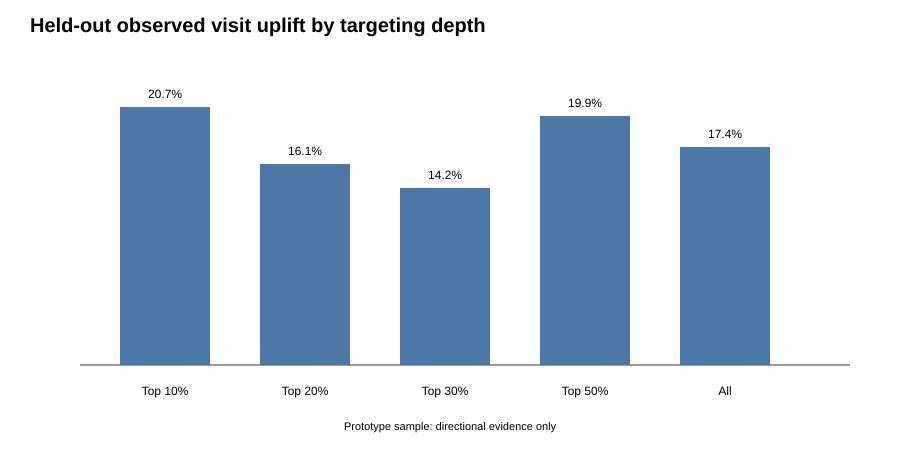

In [18]:
targeting.plot(
    x="target_fraction",
    y="observed_uplift",
    kind="bar",
    legend=False,
    figsize=(9, 5),
)

plt.ylabel("Observed visit uplift")
plt.xlabel("Top fraction by predicted uplift")
plt.title("Held-out uplift by targeting depth")
plt.tight_layout()
plt.show()

## 17. Transparent subgroup effects

In [19]:
def subgroup_uplift(
    frame,
    column,
    min_arm_n=20,
):
    rows = []

    for value, group in frame.groupby(column):
        treated = group.loc[
            group["treatment"].eq(1),
            "visit",
        ]

        control = group.loc[
            group["treatment"].eq(0),
            "visit",
        ]

        if (
            len(treated) < min_arm_n
            or len(control) < min_arm_n
        ):
            continue

        rows.append({
            column: value,
            "treated_n": len(treated),
            "control_n": len(control),
            "treated_visit": treated.mean(),
            "control_visit": control.mean(),
            "uplift": treated.mean() - control.mean(),
        })

    return pd.DataFrame(rows).sort_values(
        "uplift",
        ascending=False,
    )

for column in ["channel", "zip_code", "newbie"]:
    print()
    print(column.upper())

    print(
        subgroup_uplift(
            model_data,
            column,
        ).round(4).to_string(index=False)
    )


CHANNEL
     channel  treated_n  control_n  treated_visit  control_visit  uplift
         Web        259        182         0.2896         0.0879  0.2017
Multichannel         57         59         0.3333         0.2203  0.1130
       Phone        195        235         0.2000         0.1064  0.0936

ZIP_CODE
  zip_code  treated_n  control_n  treated_visit  control_visit  uplift
     Rural         88         76         0.3750         0.1579  0.2171
Surburban        223        219         0.2646         0.0868  0.1778
     Urban        200        181         0.2050         0.1271  0.0779

NEWBIE
 newbie  treated_n  control_n  treated_visit  control_visit  uplift
      0        265        244         0.3208         0.1434  0.1773
      1        246        232         0.1951         0.0819  0.1132

## 18. Deployment guardrails

A production version should:
1. retrain on the full customer-level randomized dataset;
2. evaluate Qini and AUUC on a large untouched holdout;
3. quantify policy uncertainty with repeated splits or bootstrap;
4. include actual campaign cost and gross margin;
5. preserve randomized holdout groups;
6. monitor drift and contact fatigue;
7. review geography and proxy features for privacy and fairness;
8. prevent post-treatment leakage.

## 19. Integrity checks

In [20]:
assert arm["n"].sum() == 64000
assert arm["visits"].sum() == 9394
assert arm["conversions"].sum() == 578

assert len(sample) == 1500
assert len(model_data) == 987
assert len(scored) == 297

assert not {
    "visit",
    "conversion",
    "spend",
}.intersection(FEATURES)

assert np.isfinite(
    scored[
        [
            "p_treat",
            "p_control",
            "uplift_score",
        ]
    ].to_numpy()
).all()

mens_conversion = tests.loc[
    tests["treatment"].eq("Mens E-Mail")
    &
    tests["outcome"].eq("conversions")
].iloc[0]

assert mens_conversion["effect"] > 0
assert mens_conversion["ci_low"] > 0

print(
    "All causal-analysis "
    "integrity checks passed ✅"
)

All causal-analysis integrity checks passed ✅

## 20. Final solution

### Experiment decision
Use Mens E-Mail as the historical default treatment.

Against the randomized no-email control:
- visit uplift: +7.66 percentage points;
- conversion uplift: +0.68 percentage points;
- relative conversion uplift: +118.8%;
- incremental revenue: +$0.77 per customer;
- roughly +68 incremental conversions and +$7,698 incremental revenue per 10,000 sends before campaign cost and margin adjustment.

### Targeting decision
When contact capacity is constrained, prioritize customers by estimated uplift rather than ordinary conversion probability.

The 1,500-row customer sample proves the modelling workflow but is deliberately treated as prototype evidence, not production validation.

### Interview-ready summary
I built a causal marketing decision system that audited a 64,000-customer randomized experiment, estimated incremental effects with uncertainty and multiple-testing control, translated them into campaign economics, then implemented a T-learner from scratch on customer-level data to demonstrate uplift-based targeting without confusing predictive probability with causality.

In [21]:
print("PROJECT 30 — FINAL DECISION")
print("=" * 60)

print("Default campaign: MENS E-MAIL")
print(
    "Conversion uplift vs control: "
    "+0.6805 percentage points"
)
print(
    "Relative conversion uplift: "
    "+118.8%"
)
print(
    "Visit uplift vs control: "
    "+7.6590 percentage points"
)
print(
    "Revenue uplift / customer: "
    "+USD 0.7698"
)
print(
    "Revenue uplift / 10k sends: "
    "+USD 7,698"
)

print()
print(
    "Uplift model: prototype "
    "demonstrated on a real "
    "customer-level sample."
)
print(
    "Production step: retrain "
    "and validate on the full "
    "customer-level RCT."
)

PROJECT 30 — FINAL DECISION
Default campaign: MENS E-MAIL
Conversion uplift vs control: +0.6805 percentage points
Relative conversion uplift: +118.8%
Visit uplift vs control: +7.6590 percentage points
Revenue uplift / customer: +USD 0.7698
Revenue uplift / 10k sends: +USD 7,698

Uplift model: prototype demonstrated on a real customer-level sample.
Production step: retrain and validate on the full customer-level RCT.